In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load_tsp_data(json_path):
    """Pomocnicza funkcja do wczytywania danych z pliku JSON."""
    try:
        with open(json_path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"Błąd: Nie znaleziono pliku {json_path}")
        return None

def draw_tsp_on_ax(ax, data, title):
    """Pomocnicza funkcja rysująca trasę na konkretnej osi (ax)."""
    nodes = data['nodes']
    tour = data['tour']
    total_dist = data['total_distance']
    total_gain = data['total_gain']

    node_map = {n['id']: n for n in nodes}
    
    # Przygotowanie współrzędnych trasy
    x_tour = [node_map[idx]['x'] for idx in tour]
    y_tour = [node_map[idx]['y'] for idx in tour]
    x_tour.append(x_tour[0])
    y_tour.append(y_tour[0])

    # Dane wszystkich punktów
    all_x = [n['x'] for n in nodes]
    all_y = [n['y'] for n in nodes]
    all_gains = [n['gain'] for n in nodes]

    # --- RYSOWANIE TRASY ---
    ax.plot(x_tour, y_tour, color='gray', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1, label='Trasa')
    
    # Strzałki kierunkowe
    for i in range(len(x_tour) - 1):
        ax.annotate('', xy=(x_tour[i+1], y_tour[i+1]), xytext=(x_tour[i], y_tour[i]),
                    arrowprops=dict(arrowstyle='->', color='black', alpha=0.3, lw=1))

    # --- RYSOWANIE PUNKTÓW ---
    min_g, max_g = min(all_gains), max(all_gains)
    sizes = [((g - min_g) / (max_g - min_g + 1e-9) * 100) + 50 for g in all_gains]

    scatter = ax.scatter(all_x, all_y, 
                         s=sizes, 
                         c=all_gains, 
                         cmap='viridis', 
                         edgecolors='white', 
                         linewidth=1, 
                         zorder=2)

    # Ustawienia osi
    ax.set_title(f"{title}\nDystans: {total_dist:.2f} | Zysk: {total_gain:.2f} | Funkcja celu: {(total_gain-total_dist):.2f}", fontsize=11)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle=':', alpha=0.5)
    
    return scatter

def plot_single_tsp_solution(json_path, title):
    """Rysuje pojedynczy wykres trasy TSP z jednego pliku JSON."""
    data = load_tsp_data(json_path)
    if not data:
        return

    # Tworzymy figurę z jedną osią
    fig, ax = plt.subplots(figsize=(10, 8))

    # Wykorzystujemy uniwersalną funkcję rysującą
    scatter = draw_tsp_on_ax(ax, data, f"{title}")

    # Dodajemy pasek kolorów (colorbar) tylko dla tego jednego wykresu
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Zysk (Gain)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

# Przykład użycia:
# plot_single_tsp_solution('solution1.json')

def plot_compare_tsp_solutions(path1, path2):
    """Główna funkcja rysująca dwa wykresy obok siebie."""
    data1 = load_tsp_data(path1)
    data2 = load_tsp_data(path2)

    if not data1 or not data2:
        return

    # Tworzenie figury z dwoma podwykresami (1 wiersz, 2 kolumny)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Rysowanie na lewej osi
    scatter1 = draw_tsp_on_ax(ax1, data1, f"Plik: {path1}")
    
    # Rysowanie na prawej osi
    scatter2 = draw_tsp_on_ax(ax2, data2, f"Plik: {path2}")

    # Dodanie wspólnego paska kolorów po prawej stronie
    cbar = fig.colorbar(scatter2, ax=[ax1, ax2], location='right', aspect=30, pad=0.05)
    cbar.set_label('Zysk (Gain)', rotation=270, labelpad=15)

    plt.suptitle("Porównanie rozwiązań TSP", fontsize=16, fontweight='bold')
    plt.show()

# Przykład użycia:
# plot_compare_tsp_solutions('solution1.json', 'solution2.json')

In [3]:

# plot_compare_tsp_solutions("NN_without_profit_TSPA.json", "NN_with_profit_TSPA.json")
# plot_single_tsp_solution("Best_RAND_TSPA.csv.json", "Random (TSPA)")
# plot_single_tsp_solution("Best_RAND_TSPB.csv.json", "Random (TSPB)")

# plot_single_tsp_solution("Best_NNa_TSPA.csv.json", "NN bez zysku (TSPA)")
# plot_single_tsp_solution("Best_NNa_TSPB.csv.json", "NN bez zysku (TSPB)")

# plot_single_tsp_solution("Best_NNp_TSPA.csv.json", "NN z zyskiem (TSPA)")
# plot_single_tsp_solution("Best_NNp_TSPB.csv.json", "NN z zyskiem (TSPB)")

# plot_single_tsp_solution("Best_GCa_TSPA.csv.json", "GC bez zysku (TSPA)")
# plot_single_tsp_solution("Best_GCa_TSPB.csv.json", "GC bez zysku (TSPB)")

# plot_single_tsp_solution("Best_GCp_TSPA.csv.json", "GC z zyskiem (TSPA)")
# plot_single_tsp_solution("Best_GCp_TSPB.csv.json", "GC z zyskiem (TSPB)")

# plot_single_tsp_solution("Best_2Ra_TSPA.csv.json", "2-żal bez zysku (TSPA)")
# plot_single_tsp_solution("Best_2Ra_TSPB.csv.json", "2-żal bez zysku (TSPB)")

# plot_single_tsp_solution("Best_2Rp_TSPA.csv.json", "2-żal z zyskiem (TSPA)")
# plot_single_tsp_solution("Best_2Rp_TSPB.csv.json", "2-żal z zyskiem (TSPB)")

# plot_single_tsp_solution("Best_2RaW_TSPA.csv.json", "2-żal ważony bez zysku (TSPA)")
# plot_single_tsp_solution("Best_2RaW_TSPB.csv.json", "2-żal ważony bez zysku (TSPB)")

# plot_single_tsp_solution("Best_2RpW_TSPB.csv.json", "2-żal ważony z zyskiem (TSPB)")


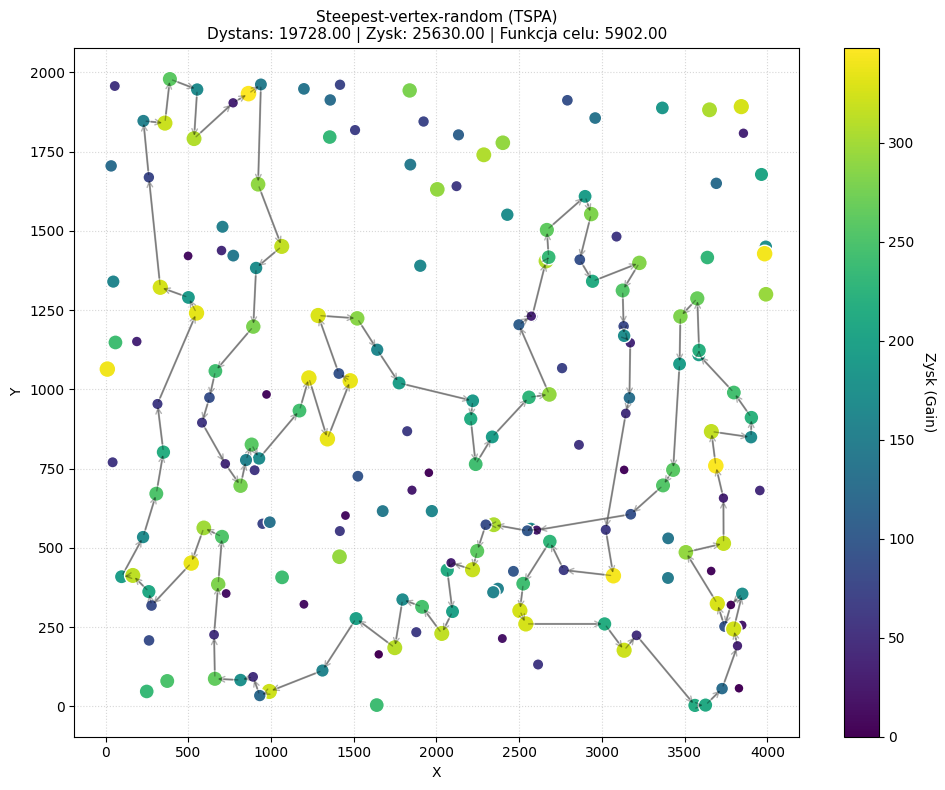

In [10]:
# plot_single_tsp_solution("Best_GV_R_TSPA.csv.json", "Greedy-vertex-random (TSPA)")
# plot_single_tsp_solution("Best_GV_R_TSPB.csv.json", "Greedy-vertex-random (TSPB)")

# plot_single_tsp_solution("Best_GE_R_TSPA.csv.json", "Greedy-edge-random (TSPA)")
# plot_single_tsp_solution("Best_GE_R_TSPB.csv.json", "Greedy-edge-random (TSPB)")

plot_single_tsp_solution("Best_SV_R_TSPA.csv.json", "Steepest-vertex-random (TSPA)")
# plot_single_tsp_solution("Best_SV_R_TSPB.csv.json", "Steepest-vertex-random (TSPB)")

# plot_single_tsp_solution("Best_SV_E_TSPA.csv.json", "Steepest-edge-random (TSPA)")
# plot_single_tsp_solution("Best_SV_E_TSPB.csv.json", "Steepest-edge-random (TSPB)")

# plot_single_tsp_solution("Best_GV_H_TSPA.csv.json", "Greedy-vertex-heuristic (TSPA)")
# plot_single_tsp_solution("Best_GV_H_TSPB.csv.json", "Greedy-vertex-heuristic (TSPB)")

# plot_single_tsp_solution("Best_GE_H_TSPA.csv.json", "Greedy-edge-heuristic (TSPA)")
# plot_single_tsp_solution("Best_GE_H_TSPB.csv.json", "Greedy-edge-heuristic (TSPB)")

# plot_single_tsp_solution("Best_SV_H_TSPA.csv.json", "Steepest-vertex-heuristic (TSPA)")
# plot_single_tsp_solution("Best_SV_H_TSPB.csv.json", "Steepest-vertex-heuristic (TSPB)")

# plot_single_tsp_solution("Best_SV_H_TSPA.csv.json", "Steepest-edge-heuristic (TSPA)")
# plot_single_tsp_solution("Best_SV_H_TSPB.csv.json", "Steepest-edge-heuristic (TSPB)")